In [1]:
from demo_core import run
import matplotlib.pyplot as plt
import torch
import numpy as np

/scratch/ar7789/.conda/llm_dataset_inference2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_noquant = True
load_quant = True

In [3]:
if load_quant:
    quant_out = torch.load("/scratch/ar7789/llm_dataset_inference/quant_out.pth", weights_only=False)
else:
    quant_out = run(quant=True)
    quant_out.save("/scratch/ar7789/llm_dataset_inference/quant_out.pth")

if load_noquant:
    noquant_out = torch.load("/scratch/ar7789/llm_dataset_inference/noquant_out.pth", weights_only=False)
else:
    noquant_out = run(quant=False)
    noquant_out.save("/scratch/ar7789/llm_dataset_inference/noquant_out.pth")

In [4]:
noquant_outs = torch.load("/scratch/ar7789/llm_dataset_inference/noquant_outs.pth", weights_only=False)
quant_outs = torch.load("/scratch/ar7789/llm_dataset_inference/quant_outs.pth", weights_only=False)

In [5]:
np.corrcoef([single_out['B_members_preds'] for single_out in quant_outs])

array([[1.        , 0.99426271, 0.99861366, 0.99818118, 0.99747656],
       [0.99426271, 1.        , 0.99802705, 0.9986472 , 0.99757221],
       [0.99861366, 0.99802705, 1.        , 0.99979026, 0.99821345],
       [0.99818118, 0.9986472 , 0.99979026, 1.        , 0.99900881],
       [0.99747656, 0.99757221, 0.99821345, 0.99900881, 1.        ]])

In [6]:
np.corrcoef([single_out['B_members_preds'] for single_out in noquant_outs])

array([[1.        , 0.99741253, 0.96932833, 0.99797701, 0.99183786],
       [0.99741253, 1.        , 0.95457989, 0.9981801 , 0.99650212],
       [0.96932833, 0.95457989, 1.        , 0.9648734 , 0.93098888],
       [0.99797701, 0.9981801 , 0.9648734 , 1.        , 0.99186176],
       [0.99183786, 0.99650212, 0.93098888, 0.99186176, 1.        ]])

In [7]:
np.corrcoef([np.array([single_out['B_members_preds'] for single_out in quant_outs]).mean(axis=0)] + [single_out['B_members_preds'] for single_out in noquant_outs])

array([[1.        , 0.14095139, 0.14292877, 0.12795519, 0.13610676,
        0.14204628],
       [0.14095139, 1.        , 0.99741253, 0.96932833, 0.99797701,
        0.99183786],
       [0.14292877, 0.99741253, 1.        , 0.95457989, 0.9981801 ,
        0.99650212],
       [0.12795519, 0.96932833, 0.95457989, 1.        , 0.9648734 ,
        0.93098888],
       [0.13610676, 0.99797701, 0.9981801 , 0.9648734 , 1.        ,
        0.99186176],
       [0.14204628, 0.99183786, 0.99650212, 0.93098888, 0.99186176,
        1.        ]])

In [8]:
np.corrcoef([np.array([single_out['B_members_preds'] for single_out in quant_outs]).mean(axis=0)] + [np.array([single_out['B_members_preds'] for single_out in noquant_outs]).mean(axis=0)])

array([[1.        , 0.13904796],
       [0.13904796, 1.        ]])

In [9]:
np.corrcoef([[single_out['B_members_preds'] for single_out in quant_outs][0]] + [single_out['B_members_preds'] for single_out in noquant_outs])

array([[1.        , 0.13776512, 0.14034115, 0.12210286, 0.13312463,
        0.14014429],
       [0.13776512, 1.        , 0.99741253, 0.96932833, 0.99797701,
        0.99183786],
       [0.14034115, 0.99741253, 1.        , 0.95457989, 0.9981801 ,
        0.99650212],
       [0.12210286, 0.96932833, 0.95457989, 1.        , 0.9648734 ,
        0.93098888],
       [0.13312463, 0.99797701, 0.9981801 , 0.9648734 , 1.        ,
        0.99186176],
       [0.14014429, 0.99183786, 0.99650212, 0.93098888, 0.99186176,
        1.        ]])

In [10]:
np.array([single_out['B_members_preds'] for single_out in quant_outs]).mean(axis=0)

array([-1.63336337e-01,  1.30120844e-01, -2.66467631e-01,  5.78091852e-02,
        7.34991208e-02,  1.52762383e-01, -3.79527718e-01, -3.59870158e-02,
       -2.40785778e-02,  2.59507596e-01, -4.24342573e-01, -3.41364086e-01,
        3.30200016e-01, -2.08440190e-03,  2.07836196e-01, -1.72447953e-02,
        7.43607432e-02,  1.34769306e-01,  1.07055746e-01,  2.03290619e-02,
        9.74167213e-02, -2.62609899e-01,  2.24856496e-01,  1.93225086e-01,
       -2.05719993e-01,  1.46522760e-01, -4.81291115e-01, -9.65899602e-02,
       -2.83541679e-02,  1.68479055e-01, -6.35858551e-02, -3.54439110e-01,
        3.94853111e-03, -1.25547543e-01, -1.61792248e-01, -1.08362613e-02,
        1.24427378e-02, -1.29438400e-01, -1.03025422e-01, -1.76673070e-01,
        1.51049614e-01, -4.32040542e-02,  1.67908609e-01,  3.21487427e-01,
        4.83479723e-03, -7.41138607e-02, -1.96132474e-02,  1.13029387e-02,
        1.73450962e-01, -1.40587706e-02, -1.41788900e-01, -3.54413748e-01,
       -1.54619012e-02, -

(array([  1.,   0.,   2.,  10., 309., 591.,  77.,   6.,   3.,   1.]),
 array([-1.88467145, -1.53219938, -1.17972732, -0.82725513, -0.47478306,
        -0.122311  ,  0.23016119,  0.58263326,  0.93510532,  1.28757739,
         1.64004946]),
 <BarContainer object of 10 artists>)

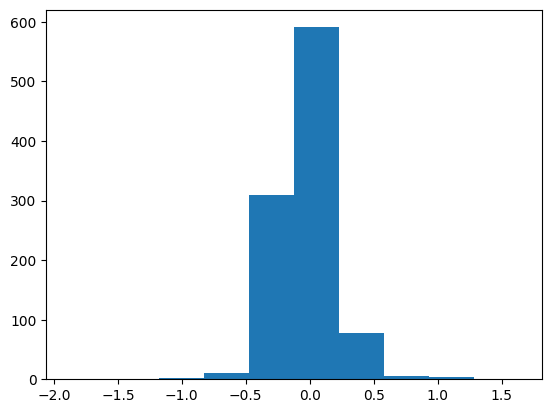

In [11]:
plt.hist([single_out['B_members_preds'] for single_out in quant_outs][0])

(array([  8., 188., 668.,  98.,  22.,   5.,   5.,   2.,   3.,   1.]),
 array([-0.61096931, -0.37504619, -0.13912311,  0.09679997,  0.33272308,
         0.56864619,  0.80456924,  1.04049242,  1.27641547,  1.51233864,
         1.74826157]),
 <BarContainer object of 10 artists>)

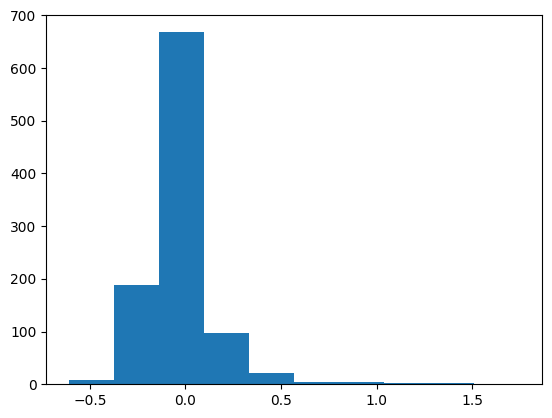

In [12]:
plt.hist([single_out['B_members_preds'] for single_out in noquant_outs][0])

In [ ]:
quant_outs = []
noquant_outs = []

for i in range(5):
    quant_outs.append(run(quant=True))
    noquant_outs.append(run(quant=False))

/scratch/ar7789/.conda/llm_dataset_inference2/lib/python3.10/site-packages/auto_gptq/nn_modules/triton_utils/kernels.py:411: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  def forward(ctx, input, qweight, scales, qzeros, g_idx, bits, maxq):
/scratch/ar7789/.conda/llm_dataset_inference2/lib/python3.10/site-packages/auto_gptq/nn_modules/triton_utils/kernels.py:419: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  def backward(ctx, grad_output):
/scratch/ar7789/.conda/llm_dataset_inference2/lib/python3.10/site-packages/auto_gptq/nn_modules/triton_utils/kernels.py:461: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=torch.float16)
CUDA extension not installed.
CUDA extension not installed.
`l

Model loaded


100%|██████████| 500/500 [00:45<00:00, 10.94it/s]


WARNING - CUSTOM: There is an infinite value in one of the populations
The null hypothesis is that the B_members scores are larger or equal than B_nonmembers.
The alternative hypothesis is that B_members (0) are lower than B_nonmembers (1) . The p-value is 0.0023204918127491757
Model loaded


100%|██████████| 500/500 [00:47<00:00, 10.62it/s]
Found modules on cpu/disk. Using Exllama/Exllamav2 backend requires all the modules to be on GPU. Setting `disable_exllama=True`


The null hypothesis is that the B_members scores are larger or equal than B_nonmembers.
The alternative hypothesis is that B_members (0) are lower than B_nonmembers (1) . The p-value is 0.0005974142439916057


Found modules on cpu/disk. Using Exllama/Exllamav2 backend requires all the modules to be on GPU. Setting `disable_exllama=True`


Model loaded


 14%|█▎        | 68/500 [00:06<00:35, 12.28it/s]

In [ ]:
torch.save(quant_outs, "/scratch/ar7789/llm_dataset_inference/quant_outs.pth")
torch.save(noquant_outs, "/scratch/ar7789/llm_dataset_inference/noquant_outs.pth")

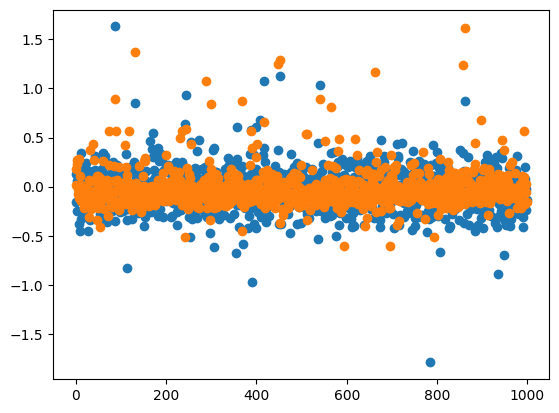

In [16]:
plt.scatter(list(range(len(quant_out['B_members_preds']))), quant_out['B_members_preds'])
plt.scatter(list(range(len(quant_out['B_members_preds']))), noquant_out['B_members_preds'])

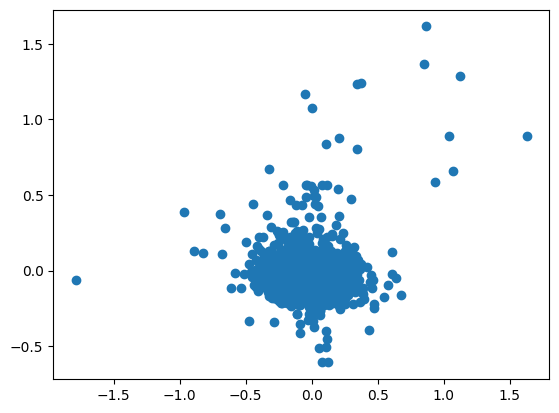

In [17]:
plt.scatter(quant_out['B_members_preds'], noquant_out['B_members_preds'])

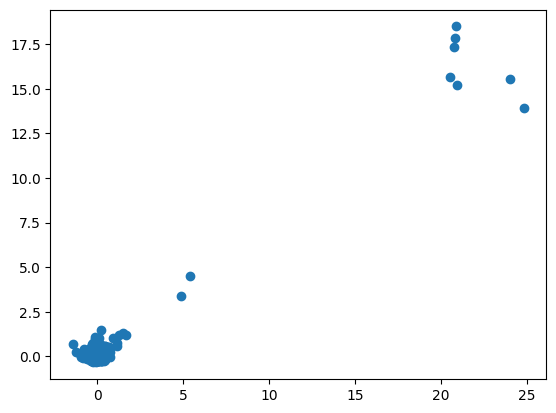

In [18]:
plt.scatter(quant_out['B_nonmembers_preds'], noquant_out['B_nonmembers_preds'])

In [21]:
import numpy as np
np.corrcoef(noquant_out['B_members_preds'], quant_out['B_members_preds'])

array([[1.        , 0.14073006],
       [0.14073006, 1.        ]])

In [8]:
np.unique((noquant_out['B_members_preds'].clip(0, 1).round() == quant_out['B_members_preds'].clip(0, 1).round()), return_counts=True)

(array([False,  True]), array([ 22, 978]))

In [9]:
np.unique(noquant_out['B_members_preds'].clip(0, 1).round(), return_counts=True)

(array([0., 1.], dtype=float32), array([977,  23]))

In [10]:
np.unique((noquant_out['B_members_preds'] * 10).round()/10., return_counts=True)

(array([-0.6, -0.5, -0.4, -0.3, -0.2, -0.1,  0. ,  0.1,  0.2,  0.3,  0.4,
         0.5,  0.6,  0.7,  0.8,  0.9,  1.1,  1.2,  1.3,  1.4,  1.6],
       dtype=float32),
 array([  2,   2,   6,  15, 122, 374, 278, 105,  43,  14,  11,   7,   7,
          2,   2,   3,   1,   3,   1,   1,   1]))

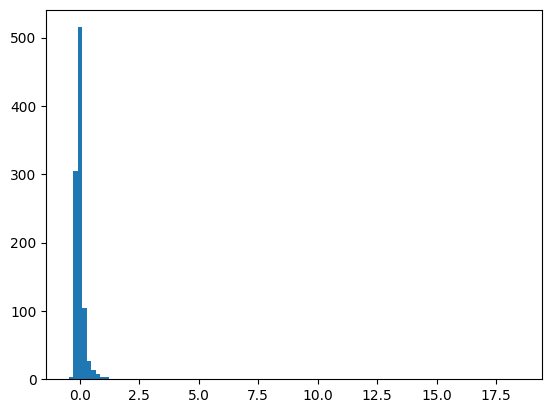

In [11]:
plt.hist(noquant_out['B_nonmembers_preds'], bins=100)
plt.show()

In [22]:
noquant_out['p_value_list'], quant_out['p_value_list']

([np.float64(0.0007827008694781798)], [np.float64(0.0028545698669677484)])